<a href="https://colab.research.google.com/github/mf2056/F20AA/blob/main/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [5]:
import pandas as pd
vad_df = pd.read_csv('train_dataset.csv')

# Cont of the ignored part in DA notebook

In [6]:
from sklearn.model_selection import train_test_split

X = vad_df["text"]
y = vad_df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=25,
    stratify=y
)

print(y_train.value_counts())
print(y_test.value_counts())

Label
positive    1278
negative     991
neutral      439
Name: count, dtype: int64
Label
positive    320
negative    247
neutral     110
Name: count, dtype: int64


In [24]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text

# Default stopwords
stop_words = text.ENGLISH_STOP_WORDS

# Keep negations
negations = {"no","nor","not"}
custom_stopwords = list(stop_words.difference(negations))

vectorizer = TfidfVectorizer(
    lowercase=True,                    # normalization
    token_pattern=r"\b[a-zA-Z]+\b",     # tokenization (only words, no punctuation)
    stop_words=custom_stopwords,       # remove stopwords but keep negations
    ngram_range=(1,2),
    # min_df=2
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [28]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
nb_pred = nb.predict(X_test_vec)


from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train_vec, y_train)
lr_pred = lr.predict(X_test_vec)


from sklearn.svm import LinearSVC

svm = LinearSVC( class_weight="balanced")
svm.fit(X_train_vec, y_train)
svm_pred = svm.predict(X_test_vec)


from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier( class_weight="balanced", random_state=30)
dt.fit(X_train_vec, y_train)
dt_pred = dt.predict(X_test_vec)

In [29]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
    print(classification_report(y_test, y_pred))

evaluate(y_test, nb_pred, "Naive Bayes")
evaluate(y_test, lr_pred, "Logistic Regression")
evaluate(y_test, svm_pred, "Linear SVM")
evaluate(y_test, dt_pred, "Decision tree")


Naive Bayes
Accuracy: 0.5214180206794683
Macro F1: 0.3072204320324621
              precision    recall  f1-score   support

    negative       0.81      0.15      0.26       247
     neutral       0.00      0.00      0.00       110
    positive       0.50      0.98      0.66       320

    accuracy                           0.52       677
   macro avg       0.44      0.38      0.31       677
weighted avg       0.53      0.52      0.41       677


Logistic Regression
Accuracy: 0.620384047267356
Macro F1: 0.5713540308474169
              precision    recall  f1-score   support

    negative       0.61      0.60      0.61       247
     neutral       0.47      0.37      0.42       110
    positive       0.66      0.72      0.69       320

    accuracy                           0.62       677
   macro avg       0.58      0.56      0.57       677
weighted avg       0.61      0.62      0.62       677


Linear SVM
Accuracy: 0.6174298375184638
Macro F1: 0.5526193948653841
              preci

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd

Accuracy = pd.DataFrame({
    "N-gram": ["(1-2) + stopwords", "(1-2)", "(1-3)", "(1-1)"],

    "Naive Bayes": [0.48, 0.47, 0.46, 0.47],

    "Logistic Regression": [0.50, 0.54, 0.52, 0.55],

    "Linear SVM": [0.54, 0.53, 0.51, 0.51]
})
Accuracy

,N-gram,Naive Bayes,Logistic Regression,Linear SVM
0,(1-2) + stopwords,0.48,0.50,0.54
1,(1-2),0.47,0.54,0.53
2,(1-3),0.46,0.52,0.51
3,(1-1),0.47,0.55,0.51


In [ ]:
Macro_F1 = pd.DataFrame({
    "N-gram": ["(1-2) + stopwords", "(1-2)", "(1-3)", "(1-1)"],

    "Naive Bayes": [0.25, 0.24, 0.22, 0.24],

    "Logistic Regression": [0.43, 0.44, 0.39, 0.47],

    "Linear SVM": [0.45, 0.42, 0.39, 0.45]
})

Macro_F1

,N-gram,Naive Bayes,Logistic Regression,Linear SVM
0,(1-2) + stopwords,0.25,0.43,0.45
1,(1-2),0.24,0.44,0.42
2,(1-3),0.22,0.39,0.39
3,(1-1),0.24,0.47,0.45


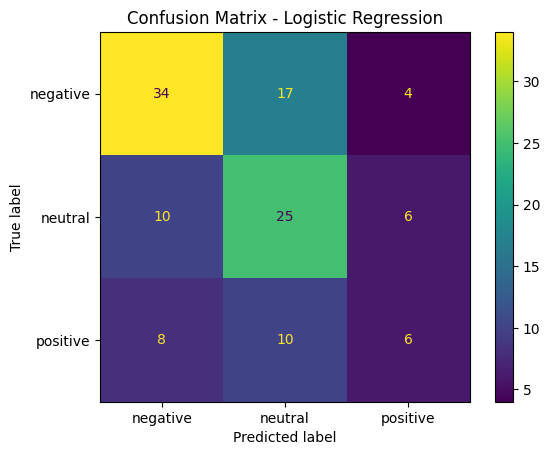

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,1))),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

scores = cross_val_score(
    pipeline,
    df["text"],
    df["manual_label"],
    cv=5,
    scoring="f1_macro"
)

accuracy = cross_val_score(
    pipeline,
    df["text"],
    df["manual_label"],
    cv=5,
    scoring="accuracy"
)

print("Cross-val Accuracy:", accuracy)
print("Mean Accuracy:", accuracy.mean())
print("Cross-val Macro F1 scores:", scores)
print("Mean Macro F1:", scores.mean())

Cross-val Accuracy: [0.55833333 0.53333333 0.5        0.575      0.51666667]
Mean Accuracy: 0.5366666666666667
Cross-val Macro F1 scores: [0.50114054 0.49773162 0.4709575  0.52046784 0.43519892]
Mean Macro F1: 0.4850992836612525


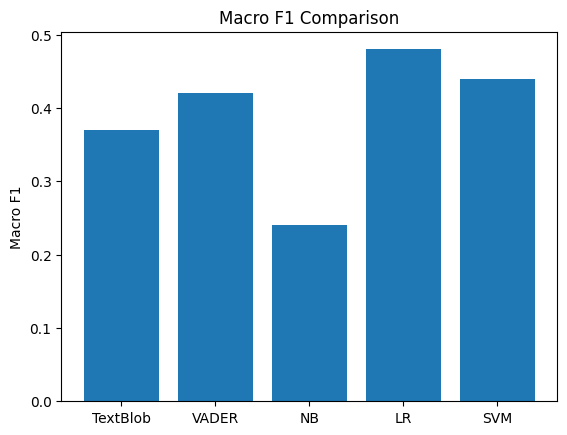

In [ ]:
models = ["TextBlob", "VADER", "NB", "LR", "SVM"]
f1_scores = [0.37, 0.42, 0.24, 0.48, 0.44]

plt.bar(models, f1_scores)
plt.title("Macro F1 Comparison")
plt.ylabel("Macro F1")
plt.show()

In [ ]:
errors = pd.DataFrame({
    "text": X_test,
    "true_label": y_test,
    "predicted_label": lr_pred
})

misclassified = errors[errors["true_label"] != errors["predicted_label"]]
misclassified.sample(10, random_state=25)

,text,true_label,predicted_label
302,$24/hr for a warehouse job? I could understan...,neutral,negative
247,"I had my first day ride along on the 17th, qui...",negative,neutral
175,I hope he pays for disrespecting his workers l...,negative,neutral
502,Love the show and I am a Hispanic who listens ...,negative,positive
154,"Lol. Yall are irrelevant as all hell, they mak...",neutral,negative
386,HAHAHAHAHA omg i just watched a liberal chick ...,negative,neutral
426,I must be lucky. I always use the bathroom and...,positive,negative
418,Ty! ❤ I'm a postal worker .. \nI definitely ap...,positive,neutral
284,You can clock in 5 before and after your shift...,neutral,positive
563,I don't mind paying the membership. Where I li...,positive,negative


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipeline_stop = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,1),
        stop_words="english",   # ← stopwords removed
        min_df=2
    )),
    ("clf", LogisticRegression(
        C=5,
        max_iter=1000,
        class_weight="balanced"
    ))
])

scores_stop = cross_val_score(
    pipeline_stop,
    df["text"],
    df["manual_label"],
    cv=5,
    scoring="f1_macro"
)

acc_stop = cross_val_score(
    pipeline_stop,
    df["text"],
    df["manual_label"],
    cv=5,
    scoring="accuracy"
)

print("Stopwords Removed - Cross-val Accuracy:", acc_stop)
print("Mean Accuracy:", acc_stop.mean())
print("Stopwords Removed - Cross-val Macro F1:", scores_stop)
print("Mean Macro F1:", scores_stop.mean())

Stopwords Removed - Cross-val Accuracy: [0.45833333 0.5        0.49166667 0.40833333 0.45      ]
Mean Accuracy: 0.4616666666666667
Stopwords Removed - Cross-val Macro F1: [0.42290274 0.46939148 0.43647628 0.35136362 0.40240081]
Mean Macro F1: 0.4165069877531581


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipeline_bigram = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),   # ← unigram + bigram
        min_df=2
    )),
    ("clf", LogisticRegression(
        C=5,
        max_iter=1000,
        class_weight="balanced"
    ))
])

scores_bigram = cross_val_score(
    pipeline_bigram,
    df["text"],
    df["manual_label"],
    cv=5,
    scoring="f1_macro"
)

acc_bigram = cross_val_score(
    pipeline_bigram,
    df["text"],
    df["manual_label"],
    cv=5,
    scoring="accuracy"
)

print("Bigram - Cross-val Accuracy:", acc_bigram)
print("Mean Accuracy:", acc_bigram.mean())
print("Bigram - Cross-val Macro F1:", scores_bigram)
print("Mean Macro F1:", scores_bigram.mean())

Bigram - Cross-val Accuracy: [0.53333333 0.54166667 0.5        0.54166667 0.525     ]
Mean Accuracy: 0.5283333333333333
Bigram - Cross-val Macro F1: [0.4681112  0.48575499 0.44295051 0.47314757 0.44323104]
Mean Macro F1: 0.46263906104591557


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipeline_count = Pipeline([
    ("count", CountVectorizer(
        ngram_range=(1,1),
        min_df=2
    )),
    ("clf", LogisticRegression(
        C=5,
        max_iter=1000,
        class_weight="balanced"
    ))
])

scores_count = cross_val_score(
    pipeline_count,
    df["text"],
    df["manual_label"],
    cv=5,
    scoring="f1_macro"
)

acc_count = cross_val_score(
    pipeline_count,
    df["text"],
    df["manual_label"],
    cv=5,
    scoring="accuracy"
)

print("CountVectorizer - Cross-val Accuracy:", acc_count)
print("Mean Accuracy:", acc_count.mean())
print("CountVectorizer - Cross-val Macro F1:", scores_count)
print("Mean Macro F1:", scores_count.mean())

CountVectorizer - Cross-val Accuracy: [0.46666667 0.50833333 0.50833333 0.48333333 0.46666667]
Mean Accuracy: 0.4866666666666667
CountVectorizer - Cross-val Macro F1: [0.43548265 0.46502829 0.47752938 0.41211359 0.4363489 ]
Mean Macro F1: 0.4453005607964645


#table for pipelines

In [ ]:
feature_names = vectorizer.get_feature_names_out()
coefs = lr.coef_

for i, label in enumerate(lr.classes_):
    top10 = coefs[i].argsort()[-10:]
    print(f"\nTop words for {label}:")
    print([feature_names[j] for j in top10])


Top words for negative:
['better', 'stop', 'employees', 'time', 'good', 'for', 'more', 'was', 'they', 'no']

Top words for neutral:
['office', 'location', 'are', 'put', 'tell', 'am', 'fedex', 'do', 'paid', 'be']

Top words for positive:
['nigga', 'years', 'work', 'keep', 'great', 'and', 'thank', 'job', 'it', 'people']


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,1)
    )),
    ("clf", LogisticRegression(
        C=5,
        max_iter=1000,
        class_weight="balanced"
    ))
])

#print out f1 and accuracy for this also then train on all manual data

# Train on ALL manual data
final_pipeline.fit(df["text"], df["manual_label"])

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf',
                 LogisticRegression(C=5, class_weight='balanced',
                                    max_iter=1000))])

In [ ]:
full_df = pd.read_csv("amazon_tb_v.csv")

In [ ]:
full_df["ml_label"] = final_pipeline.predict(full_df["text"])

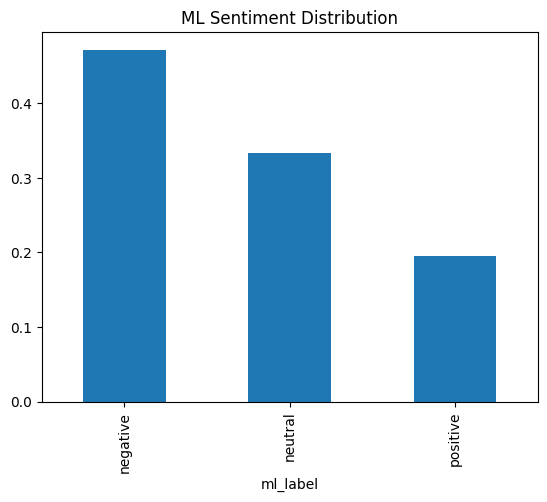

In [ ]:
import matplotlib.pyplot as plt

full_df["ml_label"].value_counts(normalize=True).plot(kind="bar")
plt.title("ML Sentiment Distribution")
plt.show()

# print top count stuff

In [ ]:
full_df["tb_label"].value_counts()

,count
tb_label,
positive,1470
neutral,1101
negative,814


In [ ]:
full_df["vader_label"].value_counts()

,count
vader_label,
positive,1777
negative,1204
neutral,404


In [ ]:
full_df["vader_label"].value_counts(normalize=True)

,proportion
vader_label,
positive,0.524963
negative,0.355687
neutral,0.119350


In [ ]:
full_df["tb_label"].value_counts(normalize=True)

,proportion
tb_label,
positive,0.434269
neutral,0.325258
negative,0.240473


In [ ]:
full_df["ml_label"].value_counts(normalize=True)

,proportion
ml_label,
negative,0.471787
neutral,0.332939
positive,0.195273


In [ ]:
df["manual_label"].value_counts(normalize=True)

,proportion
manual_label,
negative,0.458333
neutral,0.345000
positive,0.196667


In [ ]:
full_df.head()

,text,vader_label,tb_label,ml_label
0,I'm suspended for having my Medical Marijuana ...,negative,neutral,negative
1,Amazon employees are over worked with mandator...,negative,neutral,negative
2,DONT BELIEVE THE HYPE! IF MANAGEMENT DONT GIVE...,neutral,neutral,negative
3,Correct me if I am wrong. From all the people ...,positive,neutral,neutral
4,Amazon treats its workers like dirt and then a...,positive,positive,negative


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving train_dataset.csv to train_dataset.csv


In [ ]:
vad_df = pd.read_csv('train_dataset.csv')

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,1))),
    ("clf", LogisticRegression(C = 1.0, max_iter=1000, class_weight="balanced"))
])

scores = cross_val_score(
    pipeline,
    vad_df["text"],
    vad_df["Label"],
    cv=5,
    scoring="f1_macro"
)

accuracy = cross_val_score(
    pipeline,
    vad_df["text"],
    vad_df["Label"],
    cv=5,
    scoring="accuracy"
)

print("Cross-val Accuracy:", accuracy)
print("Mean Accuracy:", accuracy.mean())
print("Cross-val Macro F1 scores:", scores)
print("Mean Macro F1:", scores.mean())

Cross-val Accuracy: [0.61447563 0.61890694 0.59379616 0.61004431 0.62924668]
Mean Accuracy: 0.6132939438700148
Cross-val Macro F1 scores: [0.58119086 0.59406764 0.57139413 0.58514801 0.59812747]
Mean Macro F1: 0.5859856191079089
